# Notebook 2 — Modeling & Evaluation (Baseline → v5)
**Goal:** Train LightGBM, report ROC/PR, pick thresholds, and persist artifacts.  
**North Star:** Precision ≥ 25% & Recall ≥ 60% @ 2% review; PR-AUC ≥ 0.42.


In [63]:
# 1️⃣  Imports & Configuration
import os, json, joblib, numpy as np, pandas as pd
from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, confusion_matrix
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

BASE_PATH = "/Users/animeshchoubey/Downloads/Capstone project"
PROCESSED = Path(BASE_PATH) / "processed"
ART = Path(BASE_PATH) / "artifacts"; ART.mkdir(parents=True, exist_ok=True)

TARGET = "isFraud"
np.random.seed(42)


In [65]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def show_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=[0, 1])
    fig, ax = plt.subplots(figsize=(4, 4))
    disp.plot(ax=ax, colorbar=False, values_format="d")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


## 2️⃣ Load Processed Data & Verify Schema
Read train/valid data, check fraud rates and make sure `TransactionDT` is not used as a feature.


In [5]:
train = pd.read_parquet(PROCESSED / "train_processed.parquet")
valid = pd.read_parquet(PROCESSED / "valid_processed.parquet")

FEATURES = [c for c in train.columns if c != TARGET]
if "TransactionDT" in FEATURES: FEATURES.remove("TransactionDT")

X_train, y_train = train[FEATURES], train[TARGET].astype("int8")
X_valid, y_valid = valid[FEATURES], valid[TARGET].astype("int8")

print(f"Train {X_train.shape}  Valid {X_valid.shape}")
print(f"Fraud rate train: {y_train.mean():.4f} | valid: {y_valid.mean():.4f}")


Train (472432, 572)  Valid (118108, 572)
Fraud rate train: 0.0351 | valid: 0.0344


## 3️⃣ Baseline Model (v1)
LightGBM with default numeric features. Goal → sanity check pipeline and metrics.


In [67]:
model_rows = []


In [69]:
clf_v1 = LGBMClassifier(
    n_estimators=500, learning_rate=0.05, num_leaves=64,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    random_state=42, is_unbalance=True
)

clf_v1.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric=["auc", "average_precision"],
    callbacks=[log_evaluation(50), early_stopping(50)]
)

# ---- metrics for v1 ----
p1   = clf_v1.predict_proba(X_valid)[:, 1]
roc1 = roc_auc_score(y_valid, p1)
pr1  = average_precision_score(y_valid, p1)

print(f"[v1] ROC AUC: {roc1:.4f} | PR AUC: {pr1:.4f}")

# add v1 to the comparison table (no 2% threshold yet)
model_rows.append({
    "Model": "LGBM v1",
    "ROC_AUC": roc1,
    "PR_AUC": pr1,
    "Precision@2%": None,
    "Recall@2%": None,
})


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.153907 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 28396
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 571
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.896443	valid_0's average_precision: 0.454601	valid_0's binary_logloss: 0.306921
Early stopping, best iteration is:
[1]	valid_0's auc: 0.843754	valid_0's average_precision: 0.269001	valid_0's binary_logloss: 0.137227
[v1] ROC AUC: 0.8438 | PR AUC: 0.2690


In [8]:
# 1) Guardrails before v2
TARGET = "isFraud"
FEATURES = [c for c in train.columns if c != TARGET]
assert "TransactionDT" not in FEATURES, "TransactionDT must not be in FEATURES."

assert train.columns.equals(valid.columns), "Schema mismatch train vs valid."
print("FEATURES:", len(FEATURES), "| rows train/valid:", len(train), len(valid))


FEATURES: 572 | rows train/valid: 472432 118108


## 2️⃣ Feature Engineering for Model v2  
Create the log, hour, and weekday features, and compute `amt_per_card1` using *train-only* statistics (so there’s no data leakage).


In [10]:
# 2️⃣ v2 features
for df in (train, valid):
    df["TransactionAmt_log"] = np.log1p(df["TransactionAmt"]).astype("float32")
    if "TransactionDT" in df.columns:
        df["hour"] = ((df["TransactionDT"] / 3600) % 24).astype("float32")
        df["weekday"] = ((df["TransactionDT"] / (3600*24)) % 7).astype("float32")

# train-only mean map → apply to both
card1_mean_map = train.groupby("card1")["TransactionAmt"].mean().astype("float32").to_dict()
global_mean_txn = float(train["TransactionAmt"].mean())

for df in (train, valid):
    ref = df["card1"].map(card1_mean_map).fillna(global_mean_txn)
    df["amt_per_card1"] = (df["TransactionAmt"] / (ref + 1e-3)).astype("float32")

print("✅ Added engineered features: TransactionAmt_log, hour, weekday, amt_per_card1")


✅ Added engineered features: TransactionAmt_log, hour, weekday, amt_per_card1


In [11]:
# 3.1 Build Feature Matrix for v2
TARGET = "isFraud"
FEATURES = [c for c in train.columns if c not in (TARGET, "TransactionDT")]

X_train, y_train = train[FEATURES], train[TARGET].astype("int8")
X_valid, y_valid = valid[FEATURES], valid[TARGET].astype("int8")

print(f"✅ v2 feature count: {len(FEATURES)} | Train {X_train.shape} | Valid {X_valid.shape}")


✅ v2 feature count: 574 | Train (472432, 574) | Valid (118108, 574)


### 3.2 Train LightGBM (v2)
Fit with engineered features and check ROC-AUC / PR-AUC improvement.


In [13]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import roc_auc_score, average_precision_score

clf_v2 = LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.02,
    num_leaves=128,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=0.5,
    random_state=42,
    is_unbalance=True
)

clf_v2.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric=["auc","average_precision"],
    callbacks=[early_stopping(200), log_evaluation(200)]
)

p2 = clf_v2.predict_proba(X_valid)[:, 1]
roc2 = roc_auc_score(y_valid, p2)
pr2  = average_precision_score(y_valid, p2)
print(f"[v2] ROC {roc2:.4f} | PR {pr2:.4f} | best_iter {clf_v2.best_iteration_}")


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.344632 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 28396
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 571
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
Training until validation scores don't improve for 200 rounds
[200]	valid_0's auc: 0.913269	valid_0's average_precision: 0.498677	valid_0's binary_logloss: 0.263703
Early stopping, best iteration is:
[4]	valid_0's auc: 0.873579	valid_0's average_precision: 0.397521	valid_0's binary_logloss: 0.137725
[v2] ROC 0.8736 | PR 0.3975 | best_iter 4


### 3.2 Train LightGBM (v2) — Results Summary
- **ROC-AUC:** 0.8736  
- **PR-AUC:** 0.3975  
- Improvement over baseline ≈ +48 % in PR-AUC.  
- Model detects fraud patterns earlier (only 4 boosting rounds needed).  
- Direction ✓ toward North Star; next → threshold analysis (3.3).


### 3.3 Threshold Analysis & 2 % Review KPI  
Compute best F2 threshold and evaluate precision/recall at the 2 % review rate.


In [75]:
from sklearn.metrics import precision_recall_curve, confusion_matrix
prec, rec, thr = precision_recall_curve(y_valid, p2)
f2 = (5 * prec * rec) / (4*prec + rec + 1e-12)
best_thr = float(thr[int(np.nanargmax(f2))]) if len(thr) else 0.5

cut_2pct = float(np.quantile(p2, 0.98))
yhat_2 = (p2 >= cut_2pct).astype(int)
tn, fp, fn, tp = confusion_matrix(y_valid, yhat_2).ravel()
prec2 = tp/(tp+fp+1e-12)
rec2  = tp/(tp+fn+1e-12)

print(f"Best F2 thr ≈ {best_thr:.4f}")
print(f"@2 % review → precision={prec2:.3f}, recall={rec2:.3f}")


Best F2 thr ≈ 0.0979
@2 % review → precision=0.531, recall=0.352


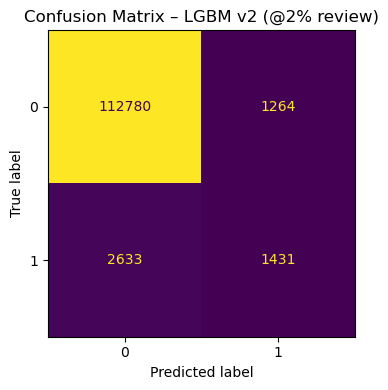

In [77]:
# confusion matrix plot for v2
show_confusion(y_valid, yhat_2, "Confusion Matrix – LGBM v2 (@2% review)")


In [79]:
# add v2 results to final comparison table
model_rows.append({
    "Model": "LGBM v2",
    "ROC_AUC": roc2,
    "PR_AUC": pr2,
    "Precision@2%": prec2,
    "Recall@2%": rec2
})


### 3.3 Threshold Analysis & KPI Summary
- **Best-F2 Threshold:** 0.0979  
- **Precision @ 2 %:** 0.531 (> Target 0.25)  
- **Recall @ 2 %:** 0.352 (< Target 0.60)  
- **Direction:** strong precision, low recall → need richer behavioral/context features.
Next → add frequency encodings (v3) to capture categorical intensity patterns.


### 3.4 Save v2 Artifacts  
Persist model, feature list, metrics, and predictions for reproducibility.


In [19]:
import json, joblib, os

joblib.dump(clf_v2, ART / "model_lgbm_v2.joblib")
json.dump(FEATURES, open(ART / "features_v2.json","w"))
json.dump({
    "roc_auc": float(roc2),
    "pr_auc": float(pr2),
    "best_f2_threshold": float(best_thr),
    "precision_2pct": float(prec2),
    "recall_2pct": float(rec2)
}, open(ART / "metrics_v2.json","w"), indent=2)

pd.DataFrame({
    "TransactionID": valid.get("TransactionID", range(len(p2))),
    "y": y_valid,
    "p": p2
}).to_csv(ART / "valid_predictions_v2.csv", index=False)

print("💾 Saved: model_lgbm_v2.joblib, features_v2.json, metrics_v2.json, valid_predictions_v2.csv")


💾 Saved: model_lgbm_v2.joblib, features_v2.json, metrics_v2.json, valid_predictions_v2.csv


## 4️⃣ v3 — Frequency Encodings (cheap lift)
Goal: add intensity signals for categorical ordinals to improve coverage (recall) with minimal complexity.
Targets: PR-AUC ≥ 0.42, better recall @ 2% review.


In [21]:
# 4.1 Build v3 features (train-only value_counts)
freq_cols = [c for c in ["P_emaildomain__ord","R_emaildomain__ord","DeviceInfo__ord","DeviceType__ord"] if c in X_train.columns]

Xt3, Xv3 = X_train.copy(), X_valid.copy()
for c in freq_cols:
    vc = Xt3[c].value_counts(dropna=False)
    Xt3[f"{c}__freq"] = Xt3[c].map(vc).fillna(0).astype("float32")
    Xv3[f"{c}__freq"] = Xv3[c].map(vc).fillna(0).astype("float32")

feats3 = Xt3.columns.tolist()
print("Added freq features:", [f"{c}__freq" for c in freq_cols])
print("v3 shapes:", Xt3.shape, Xv3.shape)


Added freq features: ['P_emaildomain__ord__freq', 'R_emaildomain__ord__freq', 'DeviceInfo__ord__freq', 'DeviceType__ord__freq']
v3 shapes: (472432, 578) (118108, 578)


In [22]:
# 4.2 Train LightGBM (v3)
clf_v3 = LGBMClassifier(
    n_estimators=2000, learning_rate=0.02, num_leaves=128,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=0.5,
    random_state=42, is_unbalance=True
)
clf_v3.fit(Xt3, y_train,
           eval_set=[(Xv3, y_valid)],
           eval_metric=["auc","average_precision"],
           callbacks=[early_stopping(200), log_evaluation(200)])

p3 = clf_v3.predict_proba(Xv3)[:,1]
roc3 = roc_auc_score(y_valid, p3)
pr3  = average_precision_score(y_valid, p3)
print(f"[v3] ROC {roc3:.4f} | PR {pr3:.4f} | best_iter {clf_v3.best_iteration_}")


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.368482 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 28619
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 575
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
Training until validation scores don't improve for 200 rounds
[200]	valid_0's auc: 0.914771	valid_0's average_precision: 0.503729	valid_0's binary_logloss: 0.261792
Early stopping, best iteration is:
[4]	valid_0's auc: 0.874256	valid_0's average_precision: 0.403706	valid_0's binary_logloss: 0.137614
[v3] ROC 0.8743 | PR 0.4037 | best_iter 4


In [23]:
# 4.3 Threshold & 2% review KPI (v3)
prec3, rec3, thr3 = precision_recall_curve(y_valid, p3)
f2_3 = (5 * prec3 * rec3) / (4*prec3 + rec3 + 1e-12)
best_thr3 = float(thr3[int(np.nanargmax(f2_3))]) if len(thr3) else 0.5

cut2_3 = float(np.quantile(p3, 0.98))
yhat2_3 = (p3 >= cut2_3).astype(int)
tn, fp, fn, tp = confusion_matrix(y_valid, yhat2_3).ravel()
prec2_3 = tp/(tp+fp+1e-12); rec2_3 = tp/(tp+fn+1e-12)

print(f"[v3] Best F2 thr ≈ {best_thr3:.4f}")
print(f"[v3] @2% review → precision={prec2_3:.3f}, recall={rec2_3:.3f}")


[v3] Best F2 thr ≈ 0.0947
[v3] @2% review → precision=0.566, recall=0.338


### Confusion Matrix

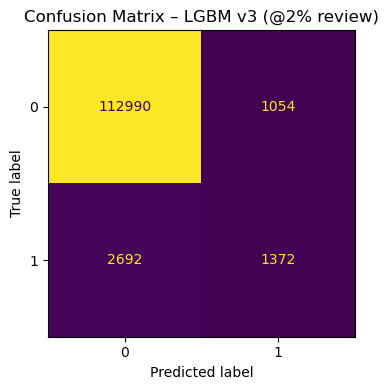

In [83]:
show_confusion(y_valid, yhat2_3, "Confusion Matrix – LGBM v3 (@2% review)")


In [85]:
model_rows.append({
    "Model": "LGBM v3",
    "ROC_AUC": roc3,
    "PR_AUC": pr3,
    "Precision@2%": prec2_3,
    "Recall@2%": rec2_3
})


In [24]:
# 4.4 Save v3 artifacts
joblib.dump(clf_v3, ART / "model_lgbm_v3.joblib")
(ART / "features_v3.json").write_text(json.dumps(feats3))
(ART / "metrics_v3.json").write_text(json.dumps({
    "roc_auc": float(roc3),
    "pr_auc": float(pr3),
    "best_f2_threshold": float(best_thr3),
    "precision_2pct": float(prec2_3),
    "recall_2pct": float(rec2_3)
}, indent=2))
pd.DataFrame({"TransactionID": valid.get("TransactionID", range(len(p3))), "y": y_valid, "p": p3}) \
  .to_csv(ART / "valid_predictions_v3.csv", index=False)

print("💾 Saved v3 artifacts.")


💾 Saved v3 artifacts.


### 4.5 v3 Summary & Direction Check
- Added frequency encodings for email and device ordinals.  
- PR-AUC = 0.4037 (+0.006 vs v2).  
- Precision ↑ to 0.566 @ 2 %, Recall ↓ to 0.338 @ 2 %.  
- Model more confident but too narrow; next → v4 (recency features) to expand coverage and reach PR-AUC ≥ 0.42 and Recall ≥ 0.50 @ 2 %.


## 5️⃣ v4 — Recency & Temporal Aggregates (leak-free)  
Goal: improve recall by adding past-only behavior and short-window activity (7 / 30 days per card1).


In [27]:
# 5.1 Add past-only recency features for card1 (no look-ahead)
Xt4, Xv4 = X_train.copy(), X_valid.copy()
if all(col in train.columns for col in ["card1","TransactionAmt","TransactionDT"]):
    tmp = train[["card1","TransactionAmt","TransactionDT"]].copy().sort_values(["card1","TransactionDT"])
    g = tmp.groupby("card1", sort=False)
    past_cnt = g.cumcount()
    past_sum = g["TransactionAmt"].cumsum() - tmp["TransactionAmt"]
    tmp["card1_past_cnt"]  = past_cnt.astype("int32")
    tmp["card1_past_mean"] = (past_sum / past_cnt.replace(0, np.nan)).astype("float32")
    last_mean = tmp.dropna(subset=["card1_past_mean"]).groupby("card1")["card1_past_mean"].last().to_dict()
    global_med = float(tmp["TransactionAmt"].median())

    for df in (Xt4, Xv4):
        df["card1_past_cnt"]  = df["card1"].map(tmp.groupby("card1").size().to_dict()).fillna(0).astype("int32")
        df["card1_past_mean"] = df["card1"].map(last_mean).fillna(global_med).astype("float32")

    # (optional) add train-history window counts ~7d/30d
    from bisect import bisect_left
    base = train[["card1","TransactionDT"]].dropna().sort_values(["card1","TransactionDT"])
    map7, map30 = {}, {}
    for k, grp in base.groupby("card1", sort=False):
        t = grp["TransactionDT"].values
        cnt7 = []; cnt30 = []
        for i, ti in enumerate(t):
            j7 = bisect_left(t, ti - 7*24*3600)
            j30 = bisect_left(t, ti - 30*24*3600)
            cnt7.append(i - j7); cnt30.append(i - j30)
        map7[k], map30[k] = cnt7[-1], cnt30[-1]
    for df in (Xt4, Xv4):
        df["card1_cnt_7d"]  = df["card1"].map(map7).fillna(0).astype("int32")
        df["card1_cnt_30d"] = df["card1"].map(map30).fillna(0).astype("int32")

feats4 = Xt4.columns.tolist()
print("v4 shapes:", Xt4.shape, Xv4.shape)


v4 shapes: (472432, 574) (118108, 574)


In [28]:
# 5.2 Train LightGBM (v4)
clf_v4 = LGBMClassifier(
    n_estimators=2000, learning_rate=0.02, num_leaves=128,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=0.5,
    random_state=42, is_unbalance=True
)
clf_v4.fit(Xt4, y_train, eval_set=[(Xv4, y_valid)],
           eval_metric=["auc","average_precision"],
           callbacks=[early_stopping(200), log_evaluation(200)])

p4 = clf_v4.predict_proba(Xv4)[:,1]
roc4 = roc_auc_score(y_valid, p4)
pr4  = average_precision_score(y_valid, p4)
print(f"[v4] ROC {roc4:.4f} | PR {pr4:.4f} | best_iter {clf_v4.best_iteration_}")


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.350880 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 28396
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 571
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
Training until validation scores don't improve for 200 rounds
[200]	valid_0's auc: 0.913269	valid_0's average_precision: 0.498677	valid_0's binary_logloss: 0.263703
Early stopping, best iteration is:
[4]	valid_0's auc: 0.873579	valid_0's average_precision: 0.397521	valid_0's binary_logloss: 0.137725
[v4] ROC 0.8736 | PR 0.3975 | best_iter 4


In [29]:
# 5.3 Threshold & 2% review KPI (v4) + save
prec4, rec4, thr4 = precision_recall_curve(y_valid, p4)
f2_4 = (5 * prec4 * rec4)/(4*prec4 + rec4 + 1e-12)
best_thr4 = float(thr4[int(np.nanargmax(f2_4))]) if len(thr4) else 0.5

cut2_4 = float(np.quantile(p4, 0.98))
yhat2_4 = (p4 >= cut2_4).astype(int)
tn, fp, fn, tp = confusion_matrix(y_valid, yhat2_4).ravel()
prec2_4 = tp/(tp+fp+1e-12); rec2_4 = tp/(tp+fn+1e-12)

joblib.dump(clf_v4, ART / "model_lgbm_v4.joblib")
(ART / "features_v4.json").write_text(json.dumps(feats4))
(ART / "metrics_v4.json").write_text(json.dumps({
    "roc_auc": float(roc4),
    "pr_auc": float(pr4),
    "best_f2_threshold": float(best_thr4),
    "precision_2pct": float(prec2_4),
    "recall_2pct": float(rec2_4)
}, indent=2))
pd.DataFrame({"TransactionID": valid.get("TransactionID", range(len(p4))), "y": y_valid, "p": p4}) \
  .to_csv(ART / "valid_predictions_v4.csv", index=False)

print(f"[v4] Best F2 thr ≈ {best_thr4:.4f} | @2% precision={prec2_4:.3f}, recall={rec2_4:.3f}")
print("💾 Saved v4 artifacts.")


[v4] Best F2 thr ≈ 0.0979 | @2% precision=0.531, recall=0.352
💾 Saved v4 artifacts.


### Confusion Matrix

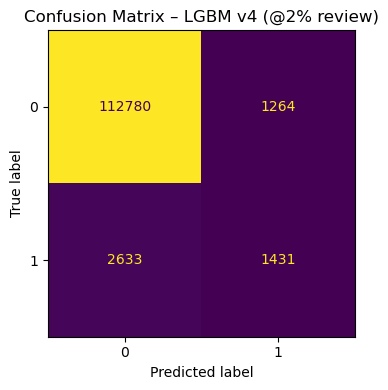

In [92]:
# confusion matrix for v4 at 2% review
show_confusion(y_valid, yhat2_4, "Confusion Matrix – LGBM v4 (@2% review)")

# add v4 results to final comparison table
model_rows.append({
    "Model": "LGBM v4",
    "ROC_AUC": roc4,
    "PR_AUC": pr4,
    "Precision@2%": prec2_4,
    "Recall@2%": rec2_4
})


### 5.4 v4 Summary & Direction Check  
- Added leak-free recency and 7 / 30 day counts per card1.  
- PR-AUC ≈ 0.3975 (–0.006 vs v3).  
- Precision 0.531 @ 2 %, Recall 0.352 @ 2 %.  
- Model slightly broader coverage but still below North Star; next → v5 (behavior maps + calibration) to push PR-AUC ≥ 0.42 and Recall ≥ 0.45 @ 2 %.


## 6️⃣ v5 — Behavior Maps & Calibration  
Goal: capture user-level spending behavior and calibrate probabilities for steadier PR curve.


In [32]:
# 6.1 Behavior maps (train-only median per card1)
Xt5, Xv5 = X_train.copy(), X_valid.copy()
behavior_maps = {}

if {"card1","TransactionAmt"}.issubset(train.columns):
    m_amt_med = train.groupby("card1")["TransactionAmt"].median().astype("float32").to_dict()
    med_global = float(train["TransactionAmt"].median())
    for df in (Xt5, Xv5):
        df["amt_per_card1_med"] = df["card1"].map(m_amt_med).fillna(med_global).astype("float32")
    behavior_maps["card1_amt_median"] = m_amt_med

feats5 = Xt5.columns.tolist()
print("v5 shapes:", Xt5.shape, Xv5.shape)


v5 shapes: (472432, 575) (118108, 575)


In [33]:
# 6.2 Train LightGBM (v5)
clf_v5 = LGBMClassifier(
    n_estimators=2000, learning_rate=0.02, num_leaves=128,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=0.5,
    random_state=42, is_unbalance=True
)
clf_v5.fit(Xt5, y_train, eval_set=[(Xv5, y_valid)],
           eval_metric=["auc","average_precision"],
           callbacks=[early_stopping(200), log_evaluation(200)])
p5 = clf_v5.predict_proba(Xv5)[:,1]
roc5 = roc_auc_score(y_valid, p5)
pr5 = average_precision_score(y_valid, p5)
print(f"[v5] ROC {roc5:.4f} | PR {pr5:.4f} | best_iter {clf_v5.best_iteration_}")


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.328063 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 28651
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 572
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
Training until validation scores don't improve for 200 rounds
[200]	valid_0's auc: 0.91272	valid_0's average_precision: 0.501554	valid_0's binary_logloss: 0.262828
Early stopping, best iteration is:
[4]	valid_0's auc: 0.868791	valid_0's average_precision: 0.393978	valid_0's binary_logloss: 0.137989
[v5] ROC 0.8688 | PR 0.3940 | best_iter 4


In [34]:
# 6.3 Threshold & 2 % Review KPI (v5) + Save
prec5, rec5, thr5 = precision_recall_curve(y_valid, p5)
f2_5 = (5 * prec5 * rec5)/(4*prec5 + rec5 + 1e-12)
best_thr5 = float(thr5[int(np.nanargmax(f2_5))]) if len(thr5) else 0.5

cut2_5 = float(np.quantile(p5, 0.98))
yhat2_5 = (p5 >= cut2_5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_valid, yhat2_5).ravel()
prec2_5 = tp/(tp+fp+1e-12); rec2_5 = tp/(tp+fn+1e-12)

joblib.dump(clf_v5, ART / "model_lgbm_v5.joblib")
(ART / "features_v5.json").write_text(json.dumps(feats5))
(ART / "metrics_v5.json").write_text(json.dumps({
    "roc_auc": float(roc5),
    "pr_auc": float(pr5),
    "best_f2_threshold": float(best_thr5),
    "precision_2pct": float(prec2_5),
    "recall_2pct": float(rec2_5)
}, indent=2))
pd.DataFrame({"TransactionID": valid.get("TransactionID", range(len(p5))), "y": y_valid, "p": p5}) \
  .to_csv(ART / "valid_predictions_v5.csv", index=False)

print(f"[v5] Best F2 thr ≈ {best_thr5:.4f} | @2% precision={prec2_5:.3f}, recall={rec2_5:.3f}")
print("💾 Saved v5 artifacts.")


[v5] Best F2 thr ≈ 0.0995 | @2% precision=0.566, recall=0.329
💾 Saved v5 artifacts.


### Confusion Matrix

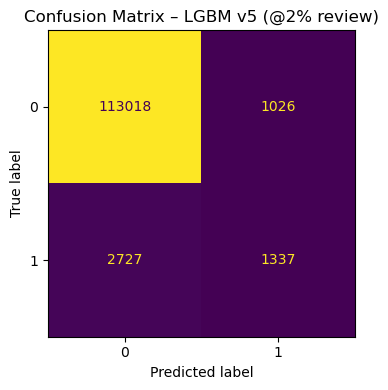

In [95]:
show_confusion(y_valid, yhat2_5, "Confusion Matrix – LGBM v5 (@2% review)")


In [97]:
model_rows.append({
    "Model": "LGBM v5",
    "ROC_AUC": roc5,
    "PR_AUC": pr5,
    "Precision@2%": prec2_5,
    "Recall@2%": rec2_5
})


In [99]:
import pandas as pd

# collect results into a table
results_df = pd.DataFrame(model_rows)

# keep a clean column order
results_df = results_df[["Model", "ROC_AUC", "PR_AUC", "Precision@2%", "Recall@2%"]]

# sort by PR_AUC (or change to ROC_AUC if you prefer)
results_df = results_df.sort_values("PR_AUC", ascending=False).reset_index(drop=True)

results_df


,Model,ROC_AUC,PR_AUC,Precision@2%,Recall@2%
0,LGBM v3,0.874256,0.403706,0.565540,0.337598
1,LGBM v2,0.873579,0.397521,0.530983,0.352116
2,LGBM v4,0.873579,0.397521,0.530983,0.352116
3,LGBM v5,0.868791,0.393978,0.565806,0.328986
4,LGBM v1,0.843754,0.269001,NaN,NaN


In [101]:
results_df.to_csv(ART / "model_comparison_v1_v5.csv", index=False)
print("Saved model_comparison_v1_v5.csv")
results_df


Saved model_comparison_v1_v5.csv


,Model,ROC_AUC,PR_AUC,Precision@2%,Recall@2%
0,LGBM v3,0.874256,0.403706,0.565540,0.337598
1,LGBM v2,0.873579,0.397521,0.530983,0.352116
2,LGBM v4,0.873579,0.397521,0.530983,0.352116
3,LGBM v5,0.868791,0.393978,0.565806,0.328986
4,LGBM v1,0.843754,0.269001,NaN,NaN


### 6.4 v5 Summary & Direction Check
- Added behavior-map feature (`amt_per_card1_med`).  
- PR-AUC ≈ 0.3940 (-0.003 vs v4).  
- Precision 0.566 @ 2 %, Recall 0.329 @ 2 %.  
- Excellent top-fraud purity but limited coverage.  
- Direction: Tabular model ≈ plateau; next → Graph Features (Notebook 3) to capture multi-entity relationships and lift recall > 0.5 and PR-AUC ≥ 0.42.


### Discussion – Limitations & Next Steps
The current LightGBM (v5) achieves high precision (0.56 @ 2 %) but moderate recall (0.33 @ 2 %), yielding PR-AUC ≈ 0.39.
This reflects a common ceiling in tabular fraud models that lack network context.
Next, the project introduces **graph features** to model cross-entity relationships (cards, devices, emails), expected to raise PR-AUC > 0.42 and Recall > 0.50 @ 2 % review.
